# Лабораторная работа №2. Временные ряды

## Чтение и восстановаление данных

In [265]:
import pandas as pd

In [266]:
xl = pd.ExcelFile("./data/have_fun.xlsx")

Исправление кодировок: "iso-8859-1" -> "windows-1251".

In [267]:
encoded_sheet_names = xl.sheet_names
decoded_sheet_names = [x.encode("iso-8859-1").decode("windows-1251") for x in encoded_sheet_names]

print(encoded_sheet_names)
print(decoded_sheet_names)

['Ëèñò1', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']
['Лист1', 'Лист2_строковые_NaN_выбросы', 'Лист3_смешанные_типы']


В инттерфейсе MS Exle: были найдены скрытые листы, установлен парамент "Показать".
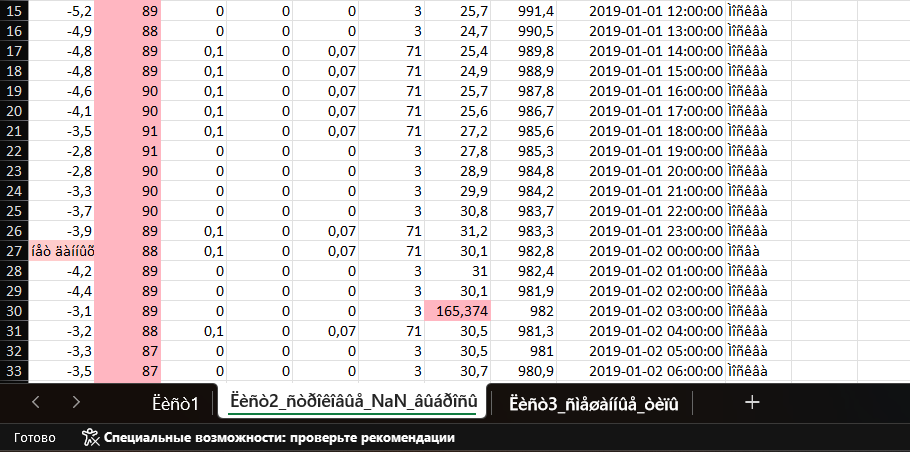

In [268]:
df_sheets = [xl.parse(sheet_name=name) for name in encoded_sheet_names]

In [269]:
df_sheets[0].info()

<class 'pandas.DataFrame'>
RangeIndex: 125124 entries, 0 to 125123
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        123249 non-null  float64       
 1   relative_humidity_2m  125124 non-null  int64         
 2   precipitation         123877 non-null  float64       
 3   rain                  125124 non-null  float64       
 4   snowfall              125124 non-null  float64       
 5   weathercode           125124 non-null  int64         
 6   wind_speed_10m        123872 non-null  float64       
 7   surface_pressure      125124 non-null  float64       
 8   ds                    125124 non-null  datetime64[us]
 9   city                  125124 non-null  str           
dtypes: datetime64[us](1), float64(6), int64(2), str(1)
memory usage: 9.5 MB


In [247]:
df_sheets[1].info()

<class 'pandas.DataFrame'>
RangeIndex: 125169 entries, 0 to 125168
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        122036 non-null  object        
 1   relative_humidity_2m  122715 non-null  float64       
 2   precipitation         122028 non-null  object        
 3   rain                  122715 non-null  float64       
 4   snowfall              122715 non-null  float64       
 5   weathercode           122714 non-null  float64       
 6   wind_speed_10m        122365 non-null  object        
 7   surface_pressure      122714 non-null  float64       
 8   ds                    122713 non-null  datetime64[us]
 9   city                  122712 non-null  str           
 10  Unnamed: 10           0 non-null       float64       
 11  Unnamed: 11           0 non-null       float64       
 12  Unnamed: 12           0 non-null       float64       
 13  Unnamed: 1

In [248]:
df_sheets[2].info()

<class 'pandas.DataFrame'>
RangeIndex: 122736 entries, 0 to 122735
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        122731 non-null  object        
 1   relative_humidity_2m  122731 non-null  float64       
 2   precipitation         122487 non-null  object        
 3   rain                  122736 non-null  float64       
 4   snowfall              122736 non-null  float64       
 5   weathercode           122736 non-null  object        
 6   wind_speed_10m        122736 non-null  object        
 7   surface_pressure      122736 non-null  float64       
 8   ds                    122736 non-null  datetime64[us]
 9   city                  122736 non-null  str           
dtypes: datetime64[us](1), float64(4), object(4), str(1)
memory usage: 9.4+ MB


In [249]:
columns_sheets = [x.columns.to_list() for x in df_sheets]

print(*columns_sheets, sep="\n")

['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']


Первые 10 колонок совпадают, но в df_sheets[2] есть вылезший блок.

### Сдвигаем первый уехавший блок

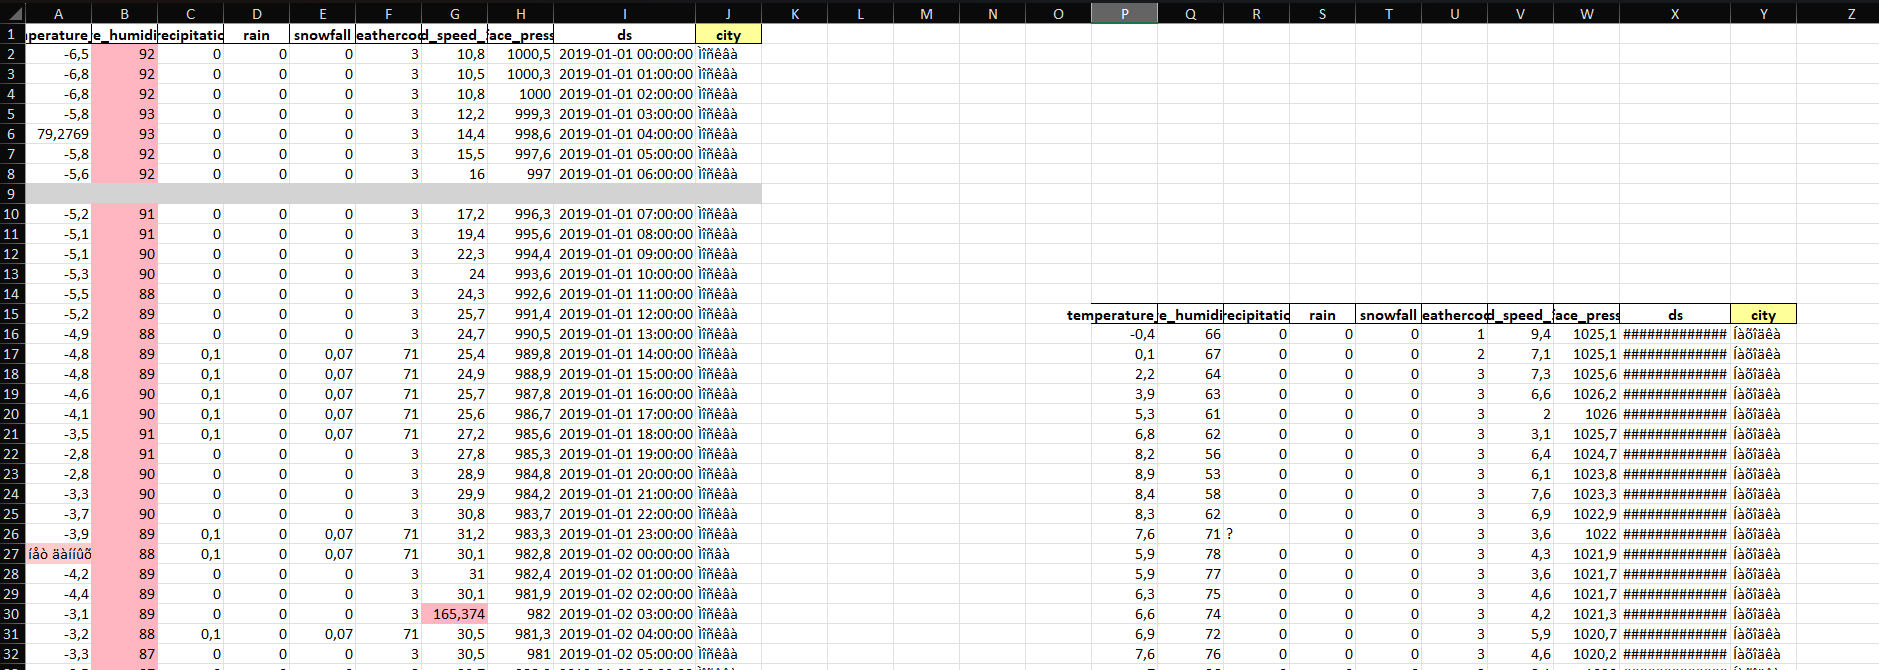
Он раскинулся не более чем на 200 первых строк.

In [250]:
print(columns_sheets[1].index("Unnamed: 15"))

df_sheets[1].iloc[13:18, 10:] # Подобрано опытным путём

15


,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
13,NaN,NaN,NaN,NaN,NaN,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
14,NaN,NaN,NaN,NaN,NaN,-0.4,66,0,0,0,1,9.4,1025.099976,2022-11-11 07:00:00,Íàõîäêà
15,NaN,NaN,NaN,NaN,NaN,0.1,67,0,0,0,2,7.1,1025.099976,2022-11-11 08:00:00,Íàõîäêà
16,NaN,NaN,NaN,NaN,NaN,2.2,64,0,0,0,3,7.3,1025.599976,2022-11-11 09:00:00,Íàõîäêà
17,NaN,NaN,NaN,NaN,NaN,3.9,63,0,0,0,3,6.6,1026.199951,2022-11-11 10:00:00,Íàõîäêà


Заметим, что съехаваший блок начинается с колонки "Unnamed: 15"

In [251]:
column_with_data = df_sheets[1].iloc[:200, 15]

start_row = column_with_data.first_valid_index()
end_row = column_with_data.last_valid_index()


broken_df = df_sheets[1].iloc[start_row + 1: end_row + 1, 15:]

broken_df.columns = df_sheets[0].columns # Устанавливаем правильный заголовок

df_sheets.append(broken_df)

### Сдвигаем второй уехавший блок

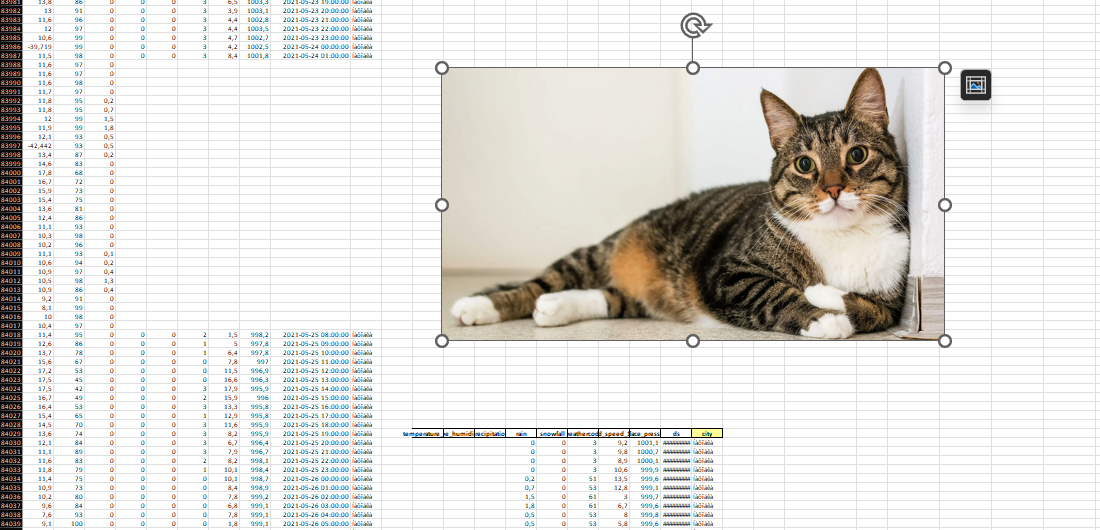    
После ручного сдвига:  
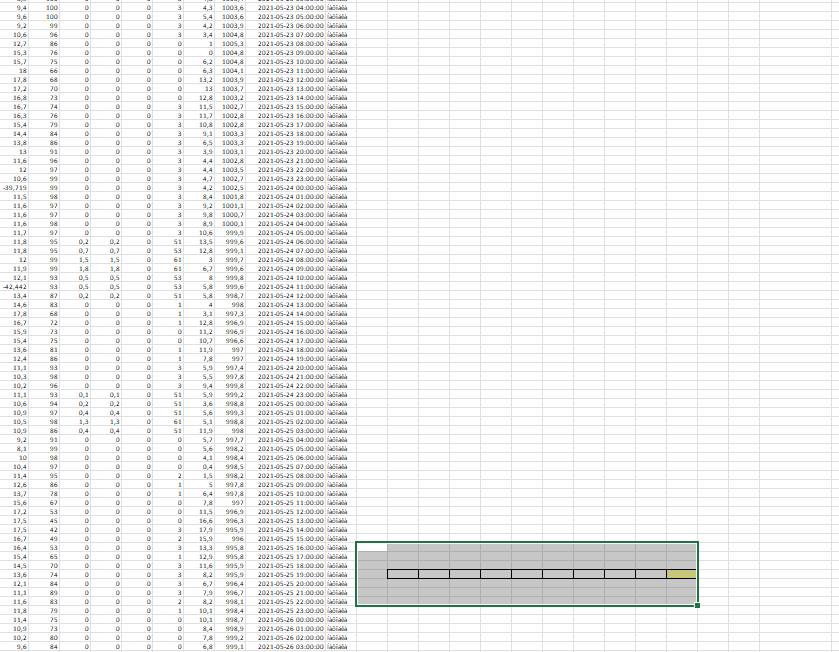

Удалим лишние столбцы из df_sheets[1].

In [252]:
df_sheets[1] = df_sheets[1].iloc[:, 0:10]

Объединим все в один df.

In [253]:
df_concated = pd.concat(df_sheets, ignore_index=True)

Приводим к правильным типам.

In [254]:
print(df_concated.columns.to_list())

['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']


Следующие колонки должны иметь числовой тип:
* temperature_2m
* relative_humidity_2m
* precipitation
* rain
* snowfall
* weathercode
* wind_speed_10m
* surface_pressure

In [255]:
numeric_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']

for col in numeric_cols:
    df_concated[col] = pd.to_numeric(df_concated[col], errors="coerce")

df_concated["ds"] = pd.to_datetime(df_concated["ds"])

In [256]:
df_concated.info()

<class 'pandas.DataFrame'>
RangeIndex: 373136 entries, 0 to 373135
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        366357 non-null  float64       
 1   relative_humidity_2m  370677 non-null  float64       
 2   precipitation         366976 non-null  float64       
 3   rain                  370682 non-null  float64       
 4   snowfall              370682 non-null  float64       
 5   weathercode           368840 non-null  float64       
 6   wind_speed_10m        367593 non-null  float64       
 7   surface_pressure      370681 non-null  float64       
 8   ds                    370680 non-null  datetime64[us]
 9   city                  370678 non-null  str           
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 28.5 MB


Удалим полностью пустые строки.

In [257]:
df_concated = df_concated.dropna(how="all")

## Исследование пропусков

In [258]:
colums = df_concated.columns.to_list()

missings = df_concated.isna().sum()
missing_percent = (df_concated.isna().sum() / len(df_concated)) * 100

report_df = pd.DataFrame({'count': missings, 'percent': missing_percent})
report_df = report_df.sort_values(by='count', ascending=False)

print(report_df)

                      count   percent
temperature_2m         4325  1.166768
precipitation          3706  0.999779
wind_speed_10m         3089  0.833329
weathercode            1842  0.496922
relative_humidity_2m      5  0.001349
city                      4  0.001079
ds                        2  0.000540
surface_pressure          1  0.000270
snowfall                  0  0.000000
rain                      0  0.000000


## Первичная обрабботка пропусков

Удалим строки, у которых есть пропуск в колонке город или время.

In [259]:
df_concated = df_concated.dropna(subset=["ds", "city"])

Восстановим кодировки.

In [260]:
df_concated["city"] = df_concated["city"].str.encode("iso-8859-1").str.decode("windows-1251")

In [264]:
df_concated.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
33772,-17.4,70.0,0.0,0.0,0.0,3.0,7.2,1003.599976,2019-01-04 16:00:00,БЛАГОВЕЩЕНСК
67373,-23.5,75.0,0.0,0.0,0.0,2.0,9.9,1005.000000,2019-01-07 23:00:00,БЛАГОВЕЩЕНСК
118404,NaN,78.0,0.0,0.0,0.0,0.0,12.6,1006.299988,2019-01-15 00:00:00,БЛАГОВЕЩЕНСК
75620,-14.7,73.0,0.0,0.0,0.0,2.0,15.9,1010.700012,2019-01-25 07:00:00,БЛАГОВЕЩЕНСК
115504,-28.4,62.0,0.0,0.0,0.0,0.0,14.4,1000.099976,2019-02-04 19:00:00,БЛАГОВЕЩЕНСК


Сортируем сперва по городам, внутри них по дате и времени.

In [262]:
df_concated = df_concated.sort_values(by=["city", "ds"])